In [4]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from moabb.pipelines.features import LogVariance
import numpy as np


In [5]:
dataset = BNCI2014_001()
num=10


In [6]:
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])


Choosing from all possible events


In [7]:
def add_gaussian_noise(X, noise_level=0.1):
    X = X.copy()

    signal_std = np.std(X)

    noise = np.random.normal(
        0,
        noise_level * signal_std,
        X.shape
    )

    return X + noise

In [ ]:
pipeline = make_pipeline(
            FunctionTransformer(add_gaussian_noise),
            CSP(n_components=8),
            LDA()
        )

In [10]:
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [11]:
results = evaluation.process({"csp+lda-missingChannels": pipeline})

Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+

         Accuracy  Balanced Accuracy  score_f1_macro
session                                             
0train   0.629966           0.629762        0.628247
1test    0.664408           0.664524        0.660976


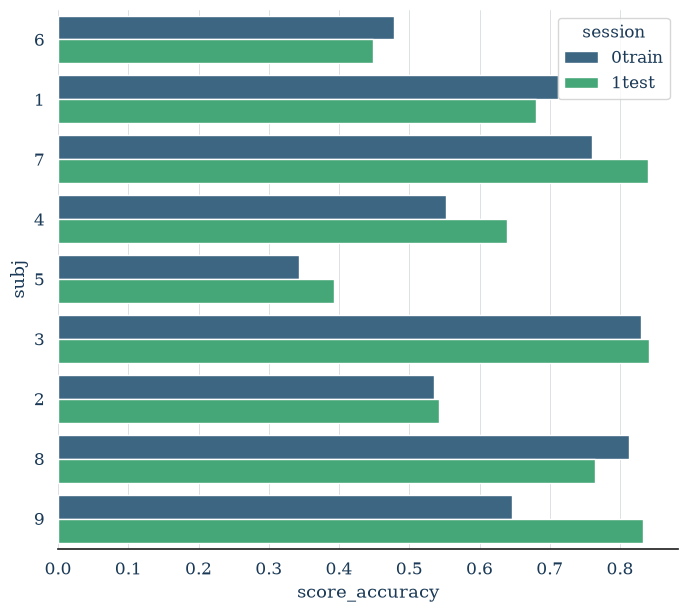

In [12]:
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

print(avgRes)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

note: change noise level and graph the accuracy changes